## 1. Introduction<br>

### About the SUPPORT2 Dataset
The SUPPORT2 dataset is comprised of data for 9105 critically ill patients in the United States between 1989-1991 and 1992-1994. The data in this dataset was originally collected for SUPPORT (Study to Understand Prognoses Preferences Outcomes and Risks of Treatment) phase II, an observational clinical trial that followed patients via medial record over the course of 2 year, or until death. It contains information about patient demographics, physiological values (i.e., blood test results), and disease information collected at the time of study entry (Day 3). The goal of this study was to predict the 2- and 6-month survival rates of critically ill patients using the information collected at Day 3.

### The Problem
In addition to improving clinical outcomes, end-of-life research like SUPPORT phase II aims to provide patients and their families with the information to make more informed decisions near the end of life. At 2 months after study entry, patients are assigned a Functional Disability Score at Month 2 (`sfdm2`). This is a validated 5-point scale for describing the level of mental and physical disability, including quality of life, at 2 months after study entry, where lower scores indicate better clinical outcomes and a higher qualty of life at the 2-month mark, whereas a higher score indicates a higher level of disability at Month 2 (note: a score of 5 means the patient has died prior to the 2-month mark, and is therefore considered a poor clinical outcome). Using the data collected at study entry, the goal is to predict the `sfdm2` score for a patient after 2 months to support earlier and better-decision making. 

**Note**: The `sfdm2` score is a measure that aggregates information from many different sources (i.e., patients themselves, caregivers, surrogates, and physicians), and is therefore a reliable descriptor of patients' level of functional disability. We acknowledge that this feature is moderately susceptible to bias. 

## 2. Methods<br>
#### 2.1 EDA <br>
The first step of our exploratory data analysis was to examine the full dataset. We began by examining the available features and targets in our dataset. Our dataset contains a total of 42 features and 3 possible targets (death, hospdead, and sfdm2). We began by better understanding what each feature label meant in order to make a more informed decision about which features to drop during feature selection. 

We dropped the following features because: 
* `adlp` and `adls` are both indices of Activities of Daily Living (ADL) and are not purely objective features. 
* `scoma`, `sps`, `aps`, and `adlsc` are all not purely objective and are model-generated values that would result in data leakage if included. 
* `totcst` and `totmcst` are redundant for `charges`, and are not features that are directly relevant to the health of patients for predicting 2-month clinical outcomes. 
* `hday` is the number of days in hospital in which a patient entered a study is not a feature that is directly relevant to the health of patients for predicting 2-month clinical outcomes. 
* `prg2m`, `prg6m` are both physician’s estimates for a patient’s 2- and 6-month survival and are therefore extremely subjective. 
* `dnr` and `dnrday` are too close of a proxy to patient status that is confounding and circular.  
* `avtisst` is a measure of the average workload of nursing staff and severity of patient’s illness and is confounding and circular.
* `dzgroup` is redundant of `dzclass`, where the former is a patient’s disease sub-category and the latter is the patient’s disease category. 

After dropping the features that were irrelevant or not purely objective, we created a pairplot to visualize the full dataset and its features. The pairplot is not indicative of any correlation between features, as most are featureless clouds. 

After encoding the categorical features and imputing the missing values (process of encoding and imputation is described in more detail below), we performed a correlation analysis using a heatmap of Pearson’s correlation coefficient. This also did not reveal a strong correlation between any of the features. We noticed some strong negative correlations between features such as `dzclass_Cancer` (patient’s disease type is cancer) and `ca_no`(patient does not have cancer), but this is relatively expected, as they are inherently opposite descriptors. 

We then performed PCA to further reduce the dimensionality of our dataset. Our eigenvalue spectrum indicated a sharp drop-off after the first 2 principal components, which explain ~86% of the total variance. The final PCA transformed data (n_components = 5) contained 98.8% of the total explained variance.

A UMAP projection of the PCA transformed data revealed no distinct clustering. All of the data points appear to be overlapping, and there also appears to be a class imbalance in the data, with a large number of data points in class 5. We tried the UMAP projection again with the non-PCA transformed data, and observed the same results. 


#### 2.2 Data Pre-Processing<br>
- Pipeline:
1. Encode categorical data
2. Training/Test split
3. Scale splits separately
4. Impute splits separately

- Encoding Methods<br>
Our initial EDA demonstrated low cardinality for all categorical features. To determine their respective encoding methods, we divided our categorical features into non-ordinal vs ordinal. Non-ordinal features such as race and sex where one hot encoded using pandas 'get_dummies'. Ordinal features were ordinally encoded manually via structured enumeration. The exact order, or ranking, of the categorical variables was specified during the encoding in order to maintain the natural, meaningful order between categories. 


- Scaling Methods<br>
We selected Standard Scaler to ensure features with inherently larger numerical magnitudes do not dominate. Values for biological data, including blood test values in our case, operate on diverse scales (i.e., concentrations vs counts). These values tend to have very different magnitudes; some numerical values end up much larger than others. Standard Scaler helps prevent these larger values from dominating, as it transforms the data to a standard distribution with a mean of 0 and standard deviation of 1. 


- Imputation Methods<br>
Initial data-processing showed that 40% of features contained NaNs. We addressed the missing data by imputing using the K-nearest neighbors method. This was our preferred method given the large percentage of missing data in our dataset. Because K-Nearest Neighbors assumes similar data points exist near eachother, it was a better alternative to other imputation methods, like mean or mode imputation, where the value calculated for the mean or mode can be heavily affected by the fraction of missing data. K-NN imputation, on the other hand, makes a prediction based on its similarity, as a function of its distance, from its neighbors. 


#### 2.3 Implemented Models<br>
- Multinomial Logistic Regression ***********TO DO***********
- Leiden Clustering ***********TO DO***********
- Gaussian Mixture Models ***********TO DO***********
- Naive Bayes ***********TO DO***********

#### 2.4 Evaluation Methods<br>
- Accuracy: To determine the accuracy of the predicted vs true labels for the training and test sets, the accuracy of supervised model’s predictions were calculated using sklearn’s accuracy_score.

- Visualization
    1. tSNE: In order to understand the resulting accuracy of our predictions, we used t-distributed stochastic neighbor embedding (t-SNE) to project our highly dimensional data into a lower dimensional space. This allowed us to observe our data on a 2D graph to observe how the dataset’s predefined classes are clustered, and if the clusters are well separated or highly overlapping. These observations were made on both the true and predicted labels of our supervised model, which helped us to identify why a model may have assigned a point to a specific cluster and to inform our fine-tune our feature pre-processing.

    2. UMAP (Leiden): For our unsupervised Leiden clustering, UMAP was the chosen visualization technique because it’s constructed using k-nearest neighbors and maintains the local and global organization of the data. This functionality of UMAP is similar to that of Leiden’s underlying architecture, and allows us to observe the clusters and their labels while maintaining a consistent and representative 2D projection between both UMAP and Leiden.

- Entropy:
    1.  Shannon's Entropy for Clustering (Hoayek et. al.):
        $$ H(i) = - \sum_{j=1}^{k} p_{ij} \log_2(p_{ij}) $$
        In this equation, i is a given data point, $p_{ij}$ is the probability that a point belongs to cluster j, and k is the number of clusters. The value calculated through Shannon's entropy represents the degree of fuzziness, where a high entropy indicates high uncertainty with the cluster classification, while low entropy indicates a relatively high confidence with the cluster classification. We implemented this evaluation method to better observe whether each data point is strongly connected to a single specific cluster or is associated with multiple clusters. For each model, we calculated the mean entropy and normalized it by dividing the mean entropy by $\log_2(Nclasses)$, so the entropy values can be better compared amongst the model.

    2. Cross Entropy Plot: (Multinomial Logistic Regression & Naive Bayes): For our MN Logistic Regression and Naive Bayes models, we chose to also implement a cross entropy plotting feature that would help us observe the how well our predicted probabilities match the true labels. This is different than its entropy value because it combines both correctness and confidence by calculating the frequency of probabilities for each class or cluster.



## 3. Implementation


In [1]:
# standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# data pre-proccessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA

# classification models
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import *
import leidenalg

# dimensionality reduction
from sklearn.manifold import TSNE

# metric tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy
import networkx as nx
from sklearn.neighbors import NearestNeighbors
import igraph as ig
import umap.umap_ as umap

# SUPPORT2
from ucimlrepo import fetch_ucirepo
support2 = fetch_ucirepo(id=880)

/Users/karaha/miniconda3/envs/msse-python/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Data Pre-Processing

In [2]:
'''Loading the data'''
def get_dataset():
    # data (as pandas dataframes)
    features = support2.data.features
    targets = support2.data.targets

    # join together as 1 df
    df = features.join(targets)
    df = df.drop(columns=['death', 'hospdead', 'adlp', 'adls', 'scoma', 'totmcst', 'totcst', 'sps', 'aps', 'hday', \
                        'adlsc', 'prg2m', 'prg6m', 'charges', 'dzgroup', 'dnr', 'dnrday', 'urine',
                        'surv2m', 'surv6m', 'avtisst']) # added surv2m, surv6m to drop; prevent data leakage

    # drop rows where target = NaN
    print(f'Before dropping NaNs in target: {df.shape[0]}')
    df = df.dropna(subset=['sfdm2'])
    print(f'After dropping NaNs in target: {df.shape[0]}')

    return df

In [4]:
def get_all_encodings(df: pd.DataFrame, combined_classes = False): 

    # isolate categorical features 
    df_to_encode = df.copy()
    numerical_feats = df.select_dtypes(include=['number']).columns.tolist() # determine numerical columns
    df_to_encode = df_to_encode.drop(numerical_feats, axis=1) # drop numerical columns

    # ------------ DUMMY ENCODING -----------
    dum_cols = ['sex', 'dzclass', 'race', 'ca']
    df_to_encode = pd.get_dummies(df, columns=dum_cols, dtype=int, drop_first=True) # keep only 1

    # ------------ ORDINAL ENCODING -----------
    # define natural order for 'income' feature
    income_order = {
        'under $11k': 0,
        '$11-$25k': 1,
        '$25-$50k': 2,
        '>$50k': 3
    }

    df_to_encode['income'] = df_to_encode['income'].map(income_order)

    if combined_classes == True: 

        # define natural order for targets (3 classes only )
        target_order = {
            'no(M2 and SIP pres)': 1, # 1 = healthy
            'adl>=4 (>=5 if sur)': 2, # 2 = moderate disability
            'SIP>=30': 2,
            'Coma or Intub': 2,
            '<2 mo. follow-up': 3     # 3 = death
        }
        
        df_to_encode['sfdm2'] = df_to_encode['sfdm2'].map(target_order)

        return df_to_encode

    # define natural order for targets (all 5 classes, original targets)
    target_order = {
        'no(M2 and SIP pres)': 1, # 1 = healthy
        'adl>=4 (>=5 if sur)': 2, 
        'SIP>=30': 3,
        'Coma or Intub': 4,
        '<2 mo. follow-up': 5     # 5 = death
    }

    df_to_encode['sfdm2'] = df_to_encode['sfdm2'].map(target_order)
    
    return df_to_encode

In [6]:
def get_class_counts(df):

    counts = df['sfdm2'].value_counts()
    plt.bar(counts.index, counts.values)
    plt.xlabel("Classes")
    plt.xticks(counts.index)  # show only integer class labels
    plt.ylabel("Counts")
    plt.title(f"Target Distribution for {len(counts.index)} Classes")
    plt.show()

    return df    

In [8]:
def perform_cosine_similarity(features, target, classes: list): 
    '''computes pairwise cosine similarity calculation to see whether some classes can be combined'''

    class_centroids = [None] * len(classes) # initialize list for storing cluster centroids

    # compute centroid for each class 
    for idx, c in enumerate(classes):
        centroid = features[target == c].mean(axis=0)
        class_centroids[idx] = centroid

    class_centroids = np.array(class_centroids)

    return cosine_similarity(class_centroids)

In [11]:
''' splitting encoded data, scaling, then imputing '''
def split_scale_impute(df):
    # -------------------------------------- Split ----------------------------------
    X = df.drop(columns=['sfdm2']) # features
    y = df[['sfdm2']] # target

    # split into training vs test data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

    # -------------------------------------- Scale all Features ----------------------------------
    scaler = StandardScaler()
    XS_train = scaler.fit_transform(X_train)
    XS_test = scaler.transform(X_test)

    # -------------------------------------- Impute ----------------------------------
    imputer = KNNImputer(n_neighbors=10) # initialize imputer

    # training
    XS_train_I = imputer.fit_transform(XS_train) # fit and transform training set

    # testing
    XS_test_I = imputer.transform(XS_test)

    # -------------------------------------- NaN Check ----------------------------------
    XS_train_I = pd.DataFrame(XS_train_I)
    XS_test_I = pd.DataFrame(XS_test_I)

    print(f"Contains missing values xtrain: {XS_train_I.isna().any().any()}")
    print(f"Contains missing values xtest: {XS_test_I.isna().any().any()}")
    print(f"Contains missing values ytrain: {y_train.isna().any().any()}")
    print(f"Contains missing values ytest: {y_test.isna().any().any()}")

    return XS_train_I, XS_test_I, y_train, y_test

In [12]:
X_train, X_test, y_train, y_test = split_scale_impute(encoded_df)

Contains missing values xtrain: False
Contains missing values xtest: False
Contains missing values ytrain: False
Contains missing values ytest: False


#### Evaluation Methods

In [13]:
''' t-SNE Visualization '''
def TSNE_visualization(x_data, trueLabels, predLabels):
    ''' Produces two t-SNE plots, comparing the true vs predicted labels '''
    le1 = LabelEncoder()
    le2 = LabelEncoder()
    trueLabels_enc = le1.fit_transform(trueLabels)
    predLabels_enc = le2.fit_transform(predLabels)

    # plot to visualize accuracy
    T = TSNE(learning_rate='auto', init='random', perplexity=30, random_state=42)
    X_TSNE = T.fit_transform(x_data) # get points

    # compare clustering
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # true labels
    ax[0].scatter(X_TSNE[:, 0], X_TSNE[:, 1], c=trueLabels_enc, cmap='cividis')
    ax[0].set_xlabel('TSNE component 1')
    ax[0].set_ylabel('TSNE component 2')
    ax[0].set_title('True Clustering')

    # predicted labels
    ax[1].scatter(X_TSNE[:, 0], X_TSNE[:, 1], c=predLabels_enc, cmap='inferno')
    ax[1].set_xlabel('TSNE component 1')
    ax[1].set_title('Predicted Clustering')

    plt.show()

    return

In [14]:
''' Entropy Evaluation '''
# TO DO

' Entropy Evaluation '

#### 3.1 Multinomial Logistic Regression <br>

In [15]:
class MN_Logistic_Regression_model:
    def __init__(self,
                 num_classes: int,
                 x_train: pd.DataFrame,
                 y_train: pd.DataFrame,
                 x_test: pd.DataFrame,
                 y_test: pd.DataFrame,
                 balance_classes: bool):

        self.y_train = np.ravel(y_train)
        self.y_test = np.ravel(y_test)
        self.x_train = x_train
        self.x_test = x_test
        self.num_classes = num_classes

        if balance_classes == True:
            my_model = LogisticRegression(class_weight='balanced')

        else:
            my_model = LogisticRegression()

        my_model.fit(self.x_train, self.y_train)

        # training predictions
        self.y_train_predLabels = my_model.predict(x_train)

        # testing predictions
        self.y_test_probabilities = my_model.predict_proba(x_test)
        self.y_test_predLabels = my_model.predict(x_test)

    def get_accuracies(self):
        test_acc = accuracy_score(self.y_test, self.y_test_predLabels) * 100
        train_acc = accuracy_score(self.y_train, self.y_train_predLabels) * 100
        print(f"training accuracy: {train_acc:.2f}%")
        print(f"testing accuracy: {test_acc:.2f}%")
        return

    def visualize_clustering(self):
        return TSNE_visualization(self.x_test, self.y_test, self.y_test_predLabels)

#### 3.2 Unsupervised Method: Leiden Clustering <br>

In [16]:
class Leiden_clustering:
    def __init__(self,
                 k: int,
                 x_data: pd.DataFrame,
                 y_data: pd.DataFrame,
                 resolution=1.0
                 ):

        nbrs = NearestNeighbors(n_neighbors=k).fit(x_data)
        distances, indices = nbrs.kneighbors(x_data)

        edges = [(i, j) for i, neigh in enumerate(indices) for j in neigh[1:]]

        My_G = nx.Graph()
        My_G.add_nodes_from(y_data)
        My_G.add_edges_from(edges)

        G = ig.Graph(n=len(x_data), edges = edges, directed = False)
        self.G = G.simplify()

        pos = nx.spectral_layout(My_G)

        self.x_data = x_data
        self.y_data = y_data

        # for single UMAP
        partition = leidenalg.find_partition(self.G, leidenalg.RBConfigurationVertexPartition, resolution_parameter = resolution)
        self.labels = np.array(partition.membership)

    def get_UMAP(self):
        ''' get 2 UMAP plots comparing the true vs predicted labels'''
        X_UMAP = umap.UMAP().fit_transform(self.x_data)
        labels = [self.y_data, self.labels]
        titles = ['True labels', 'Predicted labels']

        fig, ax = plt.subplots(1, 2, figsize=(10, 4))

        for plt_i in range(2):
            for i in range(np.max(labels[plt_i])+ 1):
                idx = np.argwhere(labels[plt_i] == i)
                ax[plt_i].scatter(X_UMAP[idx, 0], X_UMAP[idx, 1], marker = '.', alpha = 0.3, label = str(i))

            ax[plt_i].set_aspect('equal', 'datalim')
            ax[plt_i].set_title(titles[plt_i])
            ax[plt_i].legend()

        plt.tight_layout
        plt.show()

        return

#### 3.3 Unsupervised Method: Gaussian Mixture Models <br>

In [17]:
class Gaussian_Mixture_model:
    def __init__(self,
                 num_components: int,
                 rand_state: int,
                 x_data: pd.DataFrame,
                 y_data: pd.DataFrame,
                 target: str):

        self.num_components = num_components
        self.x_data = x_data
        self.y_data = y_data

        my_model = GaussianMixture(n_components = num_components, random_state = rand_state).fit(x_data)

        # extract centers and pred labels
        self.center = my_model.means_
        self.pred_label_probabilities = my_model.predict_proba(x_data)
        self.predLabels = my_model.predict(x_data)
        self.trueLabels = y_data[target].values

    def visualize_clustering(self):
        return TSNE_visualization(self.x_data, self.trueLabels, self.predLabels)

#### 3.4 Supervised Method: Naive Bayes <br>

In [18]:
class Naive_Bayes_model:
    def __init__(self,
                 num_classes: int,
                 x_train: pd.DataFrame,
                 y_train: pd.DataFrame,
                 x_test: pd.DataFrame,
                 y_test: pd.DataFrame,
                 update_priors: bool):

        self.y_train = np.ravel(y_train)
        self.y_test = np.ravel(y_test)
        self.x_train = x_train
        self.x_test = x_test
        self.num_classes = num_classes

        if update_priors == True:
            p = 1 / num_classes
            priors_list = [p] * num_classes
            my_model = GaussianNB(priors=priors_list)

        else:
            my_model = GaussianNB()

        my_model.fit(self.x_train, self.y_train)

        # training predictions
        self.y_train_predLabels = my_model.predict(x_train)

        # testing predictions
        self.y_test_probabilities = my_model.predict_proba(x_test)
        self.y_test_predLabels = my_model.predict(x_test)

    def get_accuracies(self):
        test_acc = accuracy_score(self.y_test, self.y_test_predLabels) * 100
        train_acc = accuracy_score(self.y_train, self.y_train_predLabels) * 100
        print(f"training accuracy: {train_acc:.2f}%")
        print(f"testing accuracy: {test_acc:.2f}%")
        return

    def visualize_clustering(self):
        return TSNE_visualization(self.x_test, self.y_test, self.y_test_predLabels)

## 4 Evaluation: present results, compare methods
- Table comparing accuracies
- Entropy measurement
- TSNE graphs

In [31]:
df = get_dataset()

Before dropping NaNs in target: 9105
After dropping NaNs in target: 7705


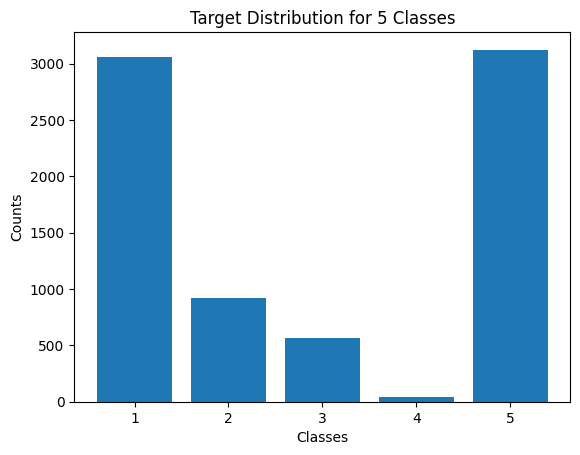

In [47]:
# initialize df w/ all classes to calculate cosine similarities 
encoded_df_all_classes = get_all_encodings(df, combined_classes=False)
counts = get_class_counts(encoded_df_all_classes)

In [49]:
features = encoded_df_all_classes.drop(columns=['sfdm2'])
target = encoded_df_all_classes['sfdm2']

similarity_result = perform_cosine_similarity(features, target, classes=[2, 3, 4])
print(similarity_result) # classes are very similar, therefore we can combine classes 2-4

[[1.         0.99983048 0.99493263]
 [0.99983048 1.         0.9946089 ]
 [0.99493263 0.9946089  1.        ]]


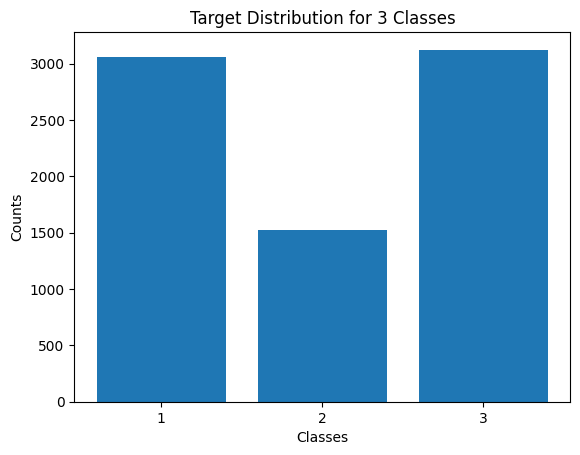

In [50]:
# from above, high similarity between classes 2, 3, 4 -> combine classes 
# re-encode df w/ 3 classes only 
encoded_df_3_classes = get_all_encodings(df, combined_classes=True)
counts = get_class_counts(encoded_df_3_classes)

In [51]:
# use final df w/ combined classes 
X_train, X_test, y_train, y_test = split_scale_impute(encoded_df_3_classes)

Contains missing values xtrain: False
Contains missing values xtest: False
Contains missing values ytrain: False
Contains missing values ytest: False


In [52]:
y_train.nunique() # confirm only 3 classes

sfdm2    3
dtype: int64

Eigenvalues and explained variance ratio:
  PC1: eigenvalue = 2.3501, explains 8.7% of variance
  PC2: eigenvalue = 2.0975, explains 7.8% of variance
  PC3: eigenvalue = 1.8184, explains 6.8% of variance
  PC4: eigenvalue = 1.6239, explains 6.0% of variance
  PC5: eigenvalue = 1.4732, explains 5.5% of variance
  PC6: eigenvalue = 1.3841, explains 5.1% of variance
  PC7: eigenvalue = 1.1492, explains 4.3% of variance
  PC8: eigenvalue = 1.0908, explains 4.1% of variance
  PC9: eigenvalue = 1.0530, explains 3.9% of variance
  PC10: eigenvalue = 1.0315, explains 3.8% of variance
  PC11: eigenvalue = 1.0099, explains 3.8% of variance
  PC12: eigenvalue = 1.0033, explains 3.7% of variance
  PC13: eigenvalue = 0.9678, explains 3.6% of variance
  PC14: eigenvalue = 0.9392, explains 3.5% of variance
  PC15: eigenvalue = 0.8491, explains 3.2% of variance
  PC16: eigenvalue = 0.8278, explains 3.1% of variance
  PC17: eigenvalue = 0.7735, explains 2.9% of variance
  PC18: eigenvalue = 0.7419, exp

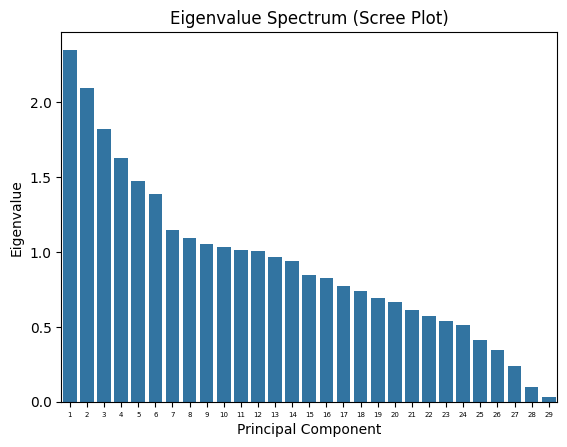

In [53]:
# examine PCA
pca = PCA()
pca.fit(X_train, y_train)

# Get eigenvalues (explained variance)
eigenvalues = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_

print("Eigenvalues and explained variance ratio:")
for i, (ev, ratio) in enumerate(zip(eigenvalues, explained_ratio)):
    print(f"  PC{i+1}: eigenvalue = {ev:.4f}, explains {ratio*100:.1f}% of variance")

print(f"\nTotal variance explained: {sum(explained_ratio)*100:.1f}%")

# Scree plot
sns.barplot(x=np.arange(1, np.max(len(eigenvalues)) + 1), y=eigenvalues)
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalue Spectrum (Scree Plot)')
plt.xticks(fontsize=5)
plt.show()

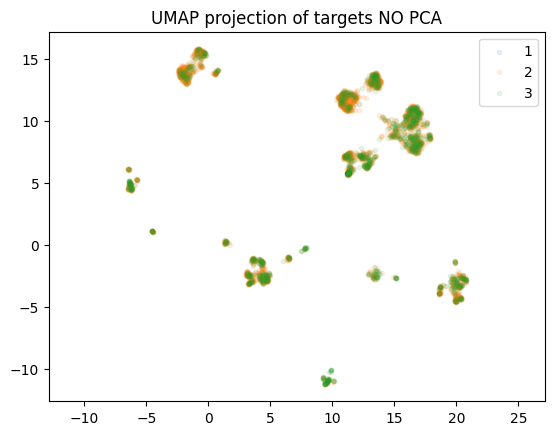

In [55]:
newXY = umap.UMAP().fit_transform(X_train)

for i in range(np.max(y_train)):
    idx = np.argwhere(y_train == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',
                alpha = 0.1, label = str(i + 1))

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of targets NO PCA')
plt.legend()
plt.show()

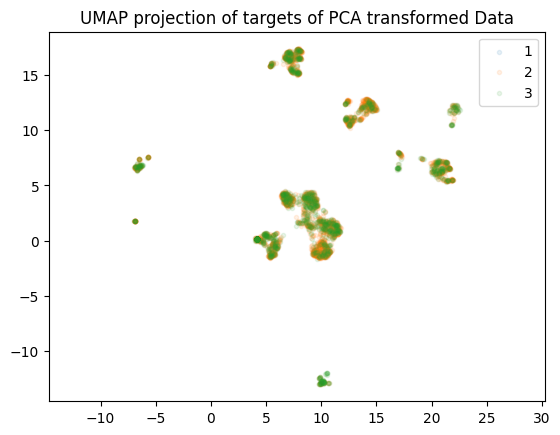

In [56]:
# refit PCA to keeping 97% of variance
pca = PCA(n_components=0.97)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

newXY = umap.UMAP().fit_transform(X_train_pca)

for i in range(np.max(y_train)):
    idx = np.argwhere(y_train == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',
                alpha = 0.1, label = str(i + 1))

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of targets of PCA transformed Data')
plt.legend()
plt.show()

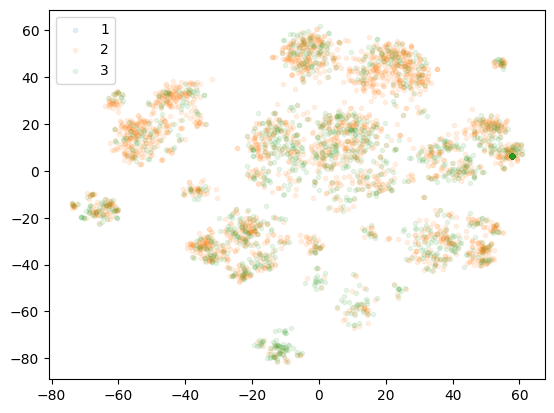

In [60]:
# PCA is not a good candidate for reducing dimensionality; try T-SNE instead 

tsne = TSNE(learning_rate='auto', init='random', perplexity=30, random_state=42)
newXY = tsne.fit_transform(X_train) 

# use train dataset to visualize dataset to see if there is any clustering 
for i in range(np.max(y_train)):
    idx = np.argwhere(y_train == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.',
                alpha = 0.1, label = str(i + 1))

plt.legend()
plt.show()

---------------------------- MN LOGISTIC REGRESSION ----------------------------
training accuracy: 51.05%
testing accuracy: 52.50%
None


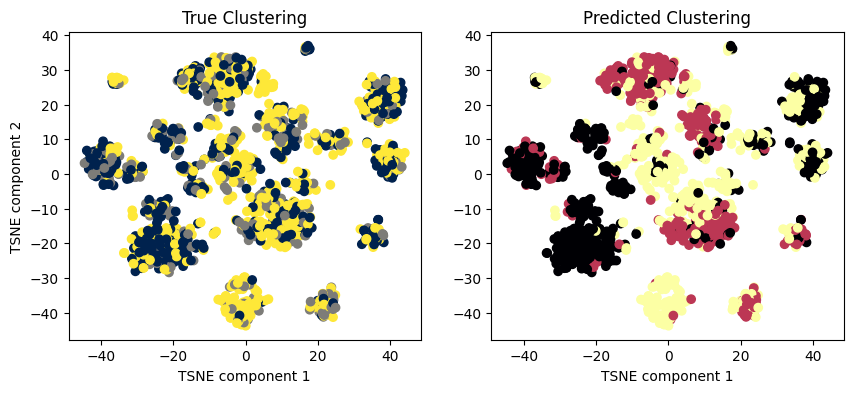

In [ ]:
# WITH PCA

print(f'---------------------------- MN LOGISTIC REGRESSION ----------------------------')
MN_LogReg = MN_Logistic_Regression_model(num_classes=3,
                                         x_train=X_train_pca,
                                         y_train=y_train,
                                         x_test=X_test_pca,
                                         y_test=y_test,
                                         balance_classes=True)

print(MN_LogReg.get_accuracies())
MN_LogReg.visualize_clustering()

---------------------------- LEIDEN MM ----------------------------


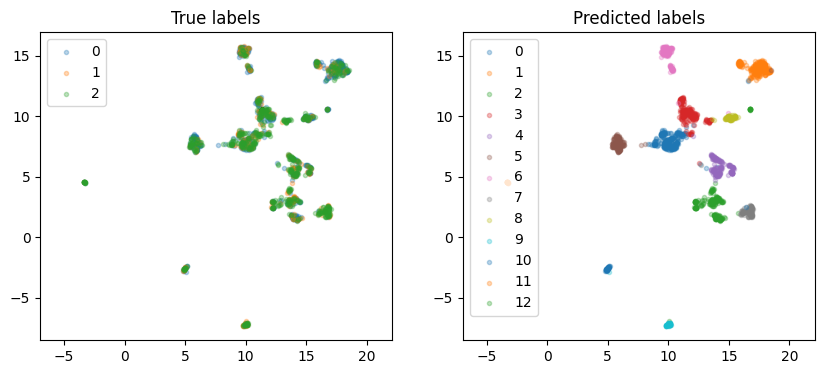

In [ ]:
print(f'---------------------------- LEIDEN MM ----------------------------')
Leiden = Leiden_clustering(k=15,
                            x_data=X_test_pca,
                            y_data=y_test)

Leiden.get_UMAP()


---------------------------- NAIVE BAYES ----------------------------
training accuracy: 48.35%
testing accuracy: 48.02%
None


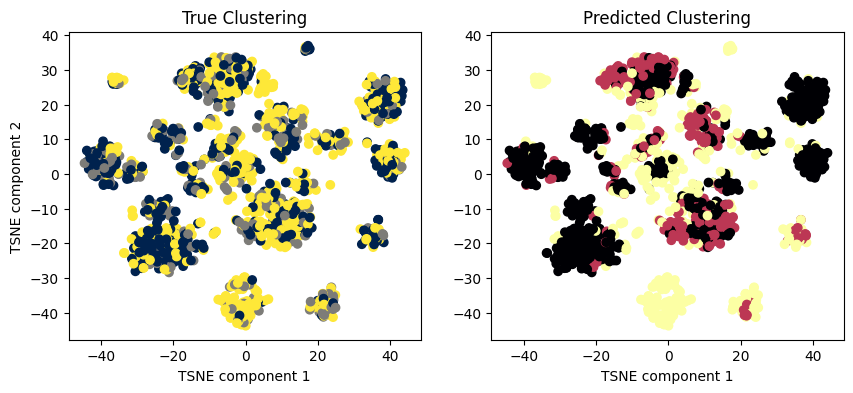

In [ ]:
print(f'---------------------------- NAIVE BAYES ----------------------------')
NB = Naive_Bayes_model(num_classes=3,
                        x_train=X_train_pca,
                        y_train=y_train,
                        x_test=X_test_pca,
                        y_test=y_test,
                        update_priors=True)

print(NB.get_accuracies())
NB.visualize_clustering()

## Discussion: interpret results, discuss model limitations and improvements

## Contribution<br>
Andy: Unsupervised modeling + fine tuning, data evaluation <br>
Anika: Data preprocessing, visualization, data evaluation <br>
Kara: Dataset selection, EDA, feature selection, limitations & improvements <br>
Yashesha: Supervised modeling + fine tuning, data evaluation <br>

## References

Hoayek, A., & Rullière, D. (2024). Assessing clustering methods using Shannon’s entropy. Information Sciences, 689, 121510. https://doi.org/10.1016/j.ins.2024.121510